unzip the folder


In [ ]:
import zipfile
import os

zip_file = "/content/drive/MyDrive/devanagari+handwritten+character+dataset (1).zip"

extract_path = "/content/devanagari_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

Dataset Path


In [ ]:
train_path = "/content/devanagari_dataset/DevanagariHandwrittenCharacterDataset/Train"
test_path = "/content/devanagari_dataset/DevanagariHandwrittenCharacterDataset/Test"

Load Training Images

In [ ]:
X_train = []
Y_train = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (32, 32))
                img = img.flatten()

                X_train.append(img)
                Y_train.append(class_name)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

print("Training data shape:", X_train.shape)
print("Training labels shape:", Y_train.shape)

Training data shape: (78200, 1024)
Training labels shape: (78200,)


Load Testing Images

In [ ]:
X_test = []
Y_test = []

for class_name in os.listdir(test_path):
    class_path = os.path.join(test_path, class_name)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (32, 32))
                img = img.flatten()

                X_test.append(img)
                Y_test.append(class_name)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

print("Testing data shape:", X_test.shape)
print("Testing labels shape:", Y_test.shape)

Testing data shape: (13800, 1024)
Testing labels shape: (13800,)


Normalize Pixel Values

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Visualizing Some Training Images

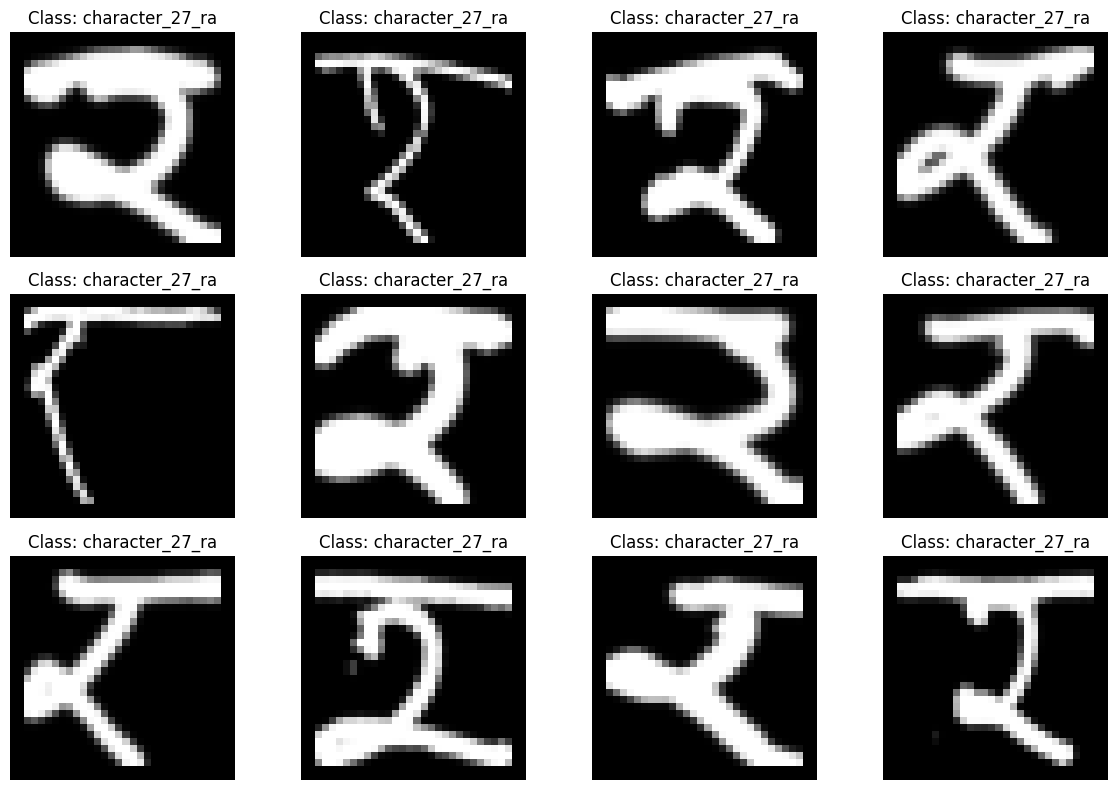

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    image = X_train[i].reshape(32, 32)

    plt.imshow(image, cmap="gray")
    plt.title("Class: " + str(Y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

Checking the Classes

In [ ]:
classes = np.unique(Y_train)

print("Number of classes:", len(classes))
print("Classes:")
print(classes)

Number of classes: 46
Classes:
['character_10_yna' 'character_11_taamatar' 'character_12_thaa'
 'character_13_daa' 'character_14_dhaa' 'character_15_adna'
 'character_16_tabala' 'character_17_tha' 'character_18_da'
 'character_19_dha' 'character_1_ka' 'character_20_na' 'character_21_pa'
 'character_22_pha' 'character_23_ba' 'character_24_bha' 'character_25_ma'
 'character_26_yaw' 'character_27_ra' 'character_28_la' 'character_29_waw'
 'character_2_kha' 'character_30_motosaw' 'character_31_petchiryakha'
 'character_32_patalosaw' 'character_33_ha' 'character_34_chhya'
 'character_35_tra' 'character_36_gya' 'character_3_ga' 'character_4_gha'
 'character_5_kna' 'character_6_cha' 'character_7_chha' 'character_8_ja'
 'character_9_jha' 'digit_0' 'digit_1' 'digit_2' 'digit_3' 'digit_4'
 'digit_5' 'digit_6' 'digit_7' 'digit_8' 'digit_9']


Train Naive Bayes

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train, Y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


Predict Test Images

In [ ]:
Y_pred = nb_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


Accuracy

In [ ]:
accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.5276086956521739
Accuracy Percentage: 52.76086956521739


Precision, Recall and F1 Score

In [ ]:
precision = precision_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5832698780704408
Recall: 0.5276086956521739
F1 Score: 0.5240016445077186


Classification Report

In [ ]:
print(classification_report(
    Y_test,
    Y_pred,
    zero_division=0
))

                           precision    recall  f1-score   support

         character_10_yna       0.64      0.65      0.64       300
    character_11_taamatar       0.82      0.68      0.74       300
        character_12_thaa       0.68      0.68      0.68       300
         character_13_daa       0.78      0.23      0.35       300
        character_14_dhaa       0.65      0.55      0.59       300
        character_15_adna       0.69      0.42      0.52       300
      character_16_tabala       0.51      0.61      0.55       300
         character_17_tha       0.61      0.24      0.34       300
          character_18_da       0.64      0.41      0.50       300
         character_19_dha       0.45      0.53      0.48       300
           character_1_ka       0.73      0.57      0.64       300
          character_20_na       0.30      0.35      0.32       300
          character_21_pa       0.33      0.62      0.43       300
         character_22_pha       0.41      0.69      0.52     

Confusion Matrix

In [ ]:
cm = confusion_matrix(
    Y_test,
    Y_pred,
    labels=classes
)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (46, 46)


Display Confusion Matrix

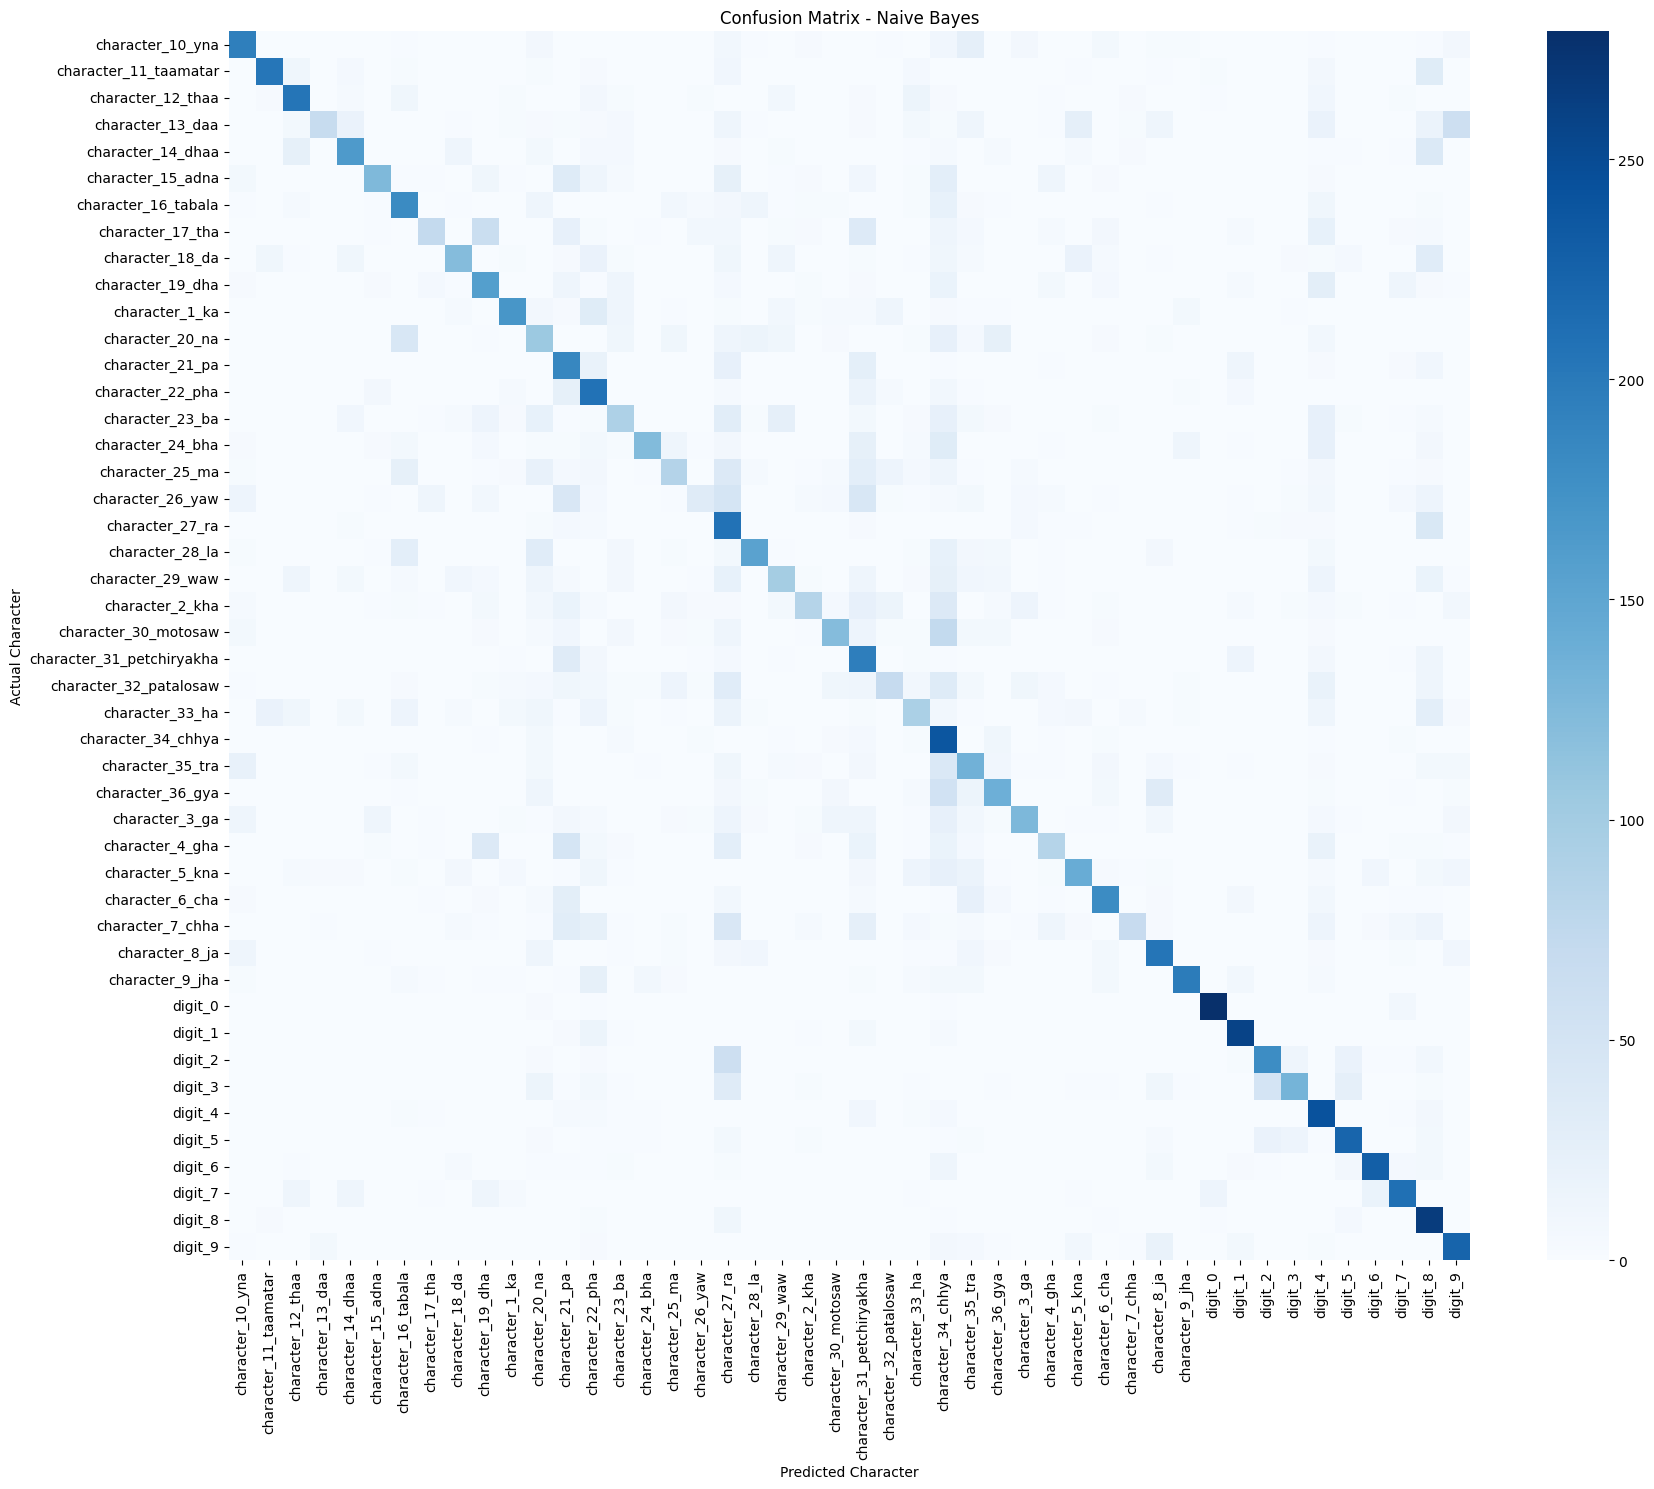

In [ ]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Character")
plt.ylabel("Actual Character")
plt.title("Confusion Matrix - Naive Bayes")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Predict One Unseen Character

Actual Character: character_27_ra
Predicted Character: character_27_ra


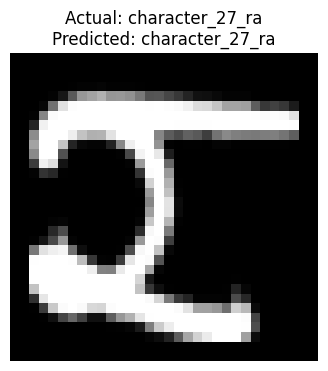

In [ ]:
index = 1

sample_image = X_test[index].reshape(32, 32)
sample = X_test[index].reshape(1, -1)

prediction = nb_model.predict(sample)

print("Actual Character:", Y_test[index])
print("Predicted Character:", prediction[0])

plt.figure(figsize=(4, 4))

plt.imshow(sample_image, cmap="gray")
plt.title(
    "Actual: " + str(Y_test[index]) +
    "\nPredicted: " + str(prediction[0])
)

plt.axis("off")
plt.show()